In [1]:
import sys
from pathlib import Path

# Notebook is inside /notebooks
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import itertools

from src.routing import generate_candidate_routes, route_travel_time
from src.toll_detector import route_tolls

Project root: /Users/hussam/Desktop/Folders/salik_optimizer


In [2]:
G = ox.load_graphml("../data/dubai.graphml")
print("Graph loaded:", len(G.nodes), "nodes")

Graph loaded: 61251 nodes


In [3]:
print("Adding speeds and travel times...")

# Estimate speeds from road types
G = ox.add_edge_speeds(G)

# Compute travel time (seconds)
G = ox.add_edge_travel_times(G)

print("Travel time attributes added.")

Adding speeds and travel times...
Travel time attributes added.


In [4]:
gates = pd.read_csv("../data/salik_gates.csv")
gates.head()

,name,lat,lon,radius_m
0,Al Barsha,25.116861,55.192619,200
1,Al Safa South,25.178158,55.247000,200
2,Al Safa North,25.193916,55.261795,200
3,Al Garhoud Bridge,25.231067,55.335624,200
4,Al Maktoum Bridge,25.252680,55.321312,200


In [5]:
zones = {
    "Marina": (25.0800, 55.1400),
    "JLT": (25.0670, 55.1410),
    "Barsha": (25.1000, 55.1800),
    "Downtown": (25.1972, 55.2744),
    "BusinessBay": (25.1860, 55.2640),
    "DXB": (25.2532, 55.3657),
    "Mirdif": (25.2240, 55.4250),
    "Qusais": (25.2760, 55.3920),
    "Deira": (25.2690, 55.3090),
    "JebelAli": (24.9850, 55.0650),
}

In [6]:
pairs = []

for (n1, c1), (n2, c2) in itertools.permutations(zones.items(), 2):
    if n1 != n2:
        pairs.append((f"{n1}→{n2}", c1, c2))

print("Total OD pairs:", len(pairs))  # should be 90 if 10 zones

Total OD pairs: 90


In [7]:
filtered_pairs = []

for name, o, d in pairs:
    dist_km = geodesic(o, d).km
    if dist_km > 10:
        filtered_pairs.append((name, o, d))

pairs = filtered_pairs
print("Filtered pairs:", len(pairs))

Filtered pairs: 70


In [8]:
MAX_PAIRS = 20  # increase later if stable
pairs_subset = pairs[:MAX_PAIRS]
len(pairs_subset)

20

In [9]:
results_all_pairs = []

for name, (olat, olon), (dlat, dlon) in pairs_subset:
    print("Running:", name)

    origin = ox.distance.nearest_nodes(G, olon, olat)
    destination = ox.distance.nearest_nodes(G, dlon, dlat)

    try:
        routes = generate_candidate_routes(G, origin, destination, k_each=8)
    except Exception as e:
        print("No path - skipped:", e)
        continue

    times_min = []
    tolls_aed = []
    toll_counts = []

    for r in routes:
        tt_sec = route_travel_time(G, r)
        tt_min = float(tt_sec) / 60.0

        toll_cost = float(route_tolls(r, G, gates))  # AED
        toll_count = int(round(toll_cost / 4.0))     # assumes 4 AED per gate

        times_min.append(tt_min)
        tolls_aed.append(toll_cost)
        toll_counts.append(toll_count)

    results_all_pairs.append({
        "name": name,
        "routes": routes,
        "times": times_min,
        "tolls": tolls_aed,
        "toll_counts": toll_counts
    })

print("Finished OD pairs:", len(results_all_pairs))

Running: Marina→Downtown
Running: Marina→BusinessBay
Running: Marina→DXB
Running: Marina→Mirdif
Running: Marina→Qusais
Running: Marina→Deira
Running: Marina→JebelAli
Running: JLT→Downtown
Running: JLT→BusinessBay
Running: JLT→DXB
Running: JLT→Mirdif
Running: JLT→Qusais
Running: JLT→Deira
Running: JLT→JebelAli
Running: Barsha→Downtown
Running: Barsha→BusinessBay
Running: Barsha→DXB
Running: Barsha→Mirdif
Running: Barsha→Qusais
Running: Barsha→Deira
Finished OD pairs: 20


In [10]:
multi_toll_cases = []
binary_cases = []

for res in results_all_pairs:
    unique_counts = set(res["toll_counts"])  # e.g. {0,1,2} or {0,2,3} etc
    
    # "non-binary" = at least 3 distinct toll-level options
    if len(unique_counts) >= 3:
        multi_toll_cases.append(res["name"])
    else:
        binary_cases.append(res["name"])

print("Total OD tested:", len(results_all_pairs))
print("Multi-toll tradeoff cases:", len(multi_toll_cases))
print("Percentage:",
      round(len(multi_toll_cases)/len(results_all_pairs)*100, 2), "%")

print("\nExamples of multi-toll cases:")
print(multi_toll_cases[:10])

Total OD tested: 20
Multi-toll tradeoff cases: 1
Percentage: 5.0 %

Examples of multi-toll cases:
['JLT→Mirdif']


In [11]:
rows = []

for res in results_all_pairs:
    for t, c, k in zip(res["times"], res["tolls"], res["toll_counts"]):
        rows.append([res["name"], t, c, k])

tradeoff_df = pd.DataFrame(
    rows,
    columns=["Route", "Travel_Time_min", "Toll_AED", "Toll_Count"]
)

tradeoff_df.to_csv("tradeoff_data.csv", index=False)
tradeoff_df.head()

,Route,Travel_Time_min,Toll_AED,Toll_Count
0,Marina→Downtown,0.246048,8.0,2
1,Marina→Downtown,0.246236,8.0,2
2,Marina→Downtown,0.246313,8.0,2
3,Marina→Downtown,0.246371,8.0,2
4,Marina→Downtown,0.246379,8.0,2


In [12]:
vot_values = [0.2, 0.5, 1.5, 3.0, 6.0]  # AED per minute

vot_results = []

for res in results_all_pairs:
    times = res["times"]
    tolls = res["tolls"]

    # Choose route minimizing: generalized_cost = (time * vot) + toll
    for vot in vot_values:
        best_idx = min(
            range(len(times)),
            key=lambda i: times[i] * vot + tolls[i]
        )

        vot_results.append({
            "Route": res["name"],
            "VOT": vot,
            "Chosen_Time": times[best_idx],
            "Chosen_Toll": tolls[best_idx],
            "Chosen_Toll_Count": int(round(tolls[best_idx] / 4.0))
        })

vot_df = pd.DataFrame(vot_results)
vot_df.head()

,Route,VOT,Chosen_Time,Chosen_Toll,Chosen_Toll_Count
0,Marina→Downtown,0.2,0.246048,8.0,2
1,Marina→Downtown,0.5,0.246048,8.0,2
2,Marina→Downtown,1.5,0.246048,8.0,2
3,Marina→Downtown,3.0,0.246048,8.0,2
4,Marina→Downtown,6.0,0.246048,8.0,2


In [13]:
for route in vot_df["Route"].unique():
    sub = vot_df[vot_df["Route"] == route].sort_values("VOT")

    print("\n====================")
    print(route)

    prev = None
    for _, row in sub.iterrows():
        if prev is None or row["Chosen_Toll"] != prev:
            print(
                f"VOT={row['VOT']}: "
                f"{row['Chosen_Time']:.2f} min, "
                f"{row['Chosen_Toll']:.0f} AED "
                f"({int(row['Chosen_Toll_Count'])} gates)"
            )
        prev = row["Chosen_Toll"]


Marina→Downtown
VOT=0.2: 0.25 min, 8 AED (2 gates)

Marina→BusinessBay
VOT=0.2: 0.22 min, 8 AED (2 gates)

Marina→DXB
VOT=0.2: 0.42 min, 12 AED (3 gates)

Marina→Mirdif
VOT=0.2: 0.46 min, 12 AED (3 gates)

Marina→Qusais
VOT=0.2: 0.47 min, 12 AED (3 gates)

Marina→Deira
VOT=0.2: 0.45 min, 0 AED (0 gates)

Marina→JebelAli
VOT=0.2: 0.21 min, 4 AED (1 gates)

JLT→Downtown
VOT=0.2: 0.27 min, 8 AED (2 gates)

JLT→BusinessBay
VOT=0.2: 0.25 min, 8 AED (2 gates)

JLT→DXB
VOT=0.2: 0.45 min, 12 AED (3 gates)

JLT→Mirdif
VOT=0.2: 0.48 min, 0 AED (0 gates)

JLT→Qusais
VOT=0.2: 0.49 min, 12 AED (3 gates)

JLT→Deira
VOT=0.2: 0.50 min, 0 AED (0 gates)

JLT→JebelAli
VOT=0.2: 0.25 min, 0 AED (0 gates)

Barsha→Downtown
VOT=0.2: 0.19 min, 8 AED (2 gates)

Barsha→BusinessBay
VOT=0.2: 0.17 min, 8 AED (2 gates)

Barsha→DXB
VOT=0.2: 0.37 min, 12 AED (3 gates)

Barsha→Mirdif
VOT=0.2: 0.48 min, 0 AED (0 gates)

Barsha→Qusais
VOT=0.2: 0.42 min, 12 AED (3 gates)

Barsha→Deira
VOT=0.2: 0.37 min, 4 AED (1 gates)


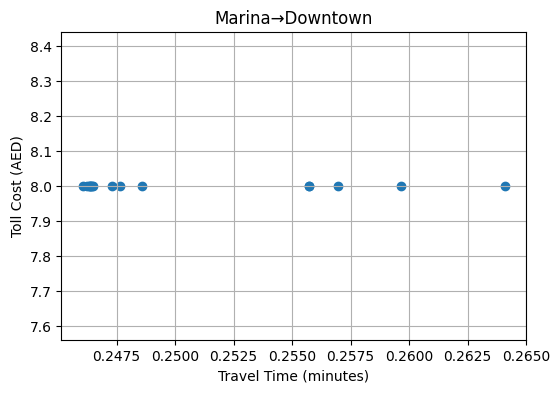

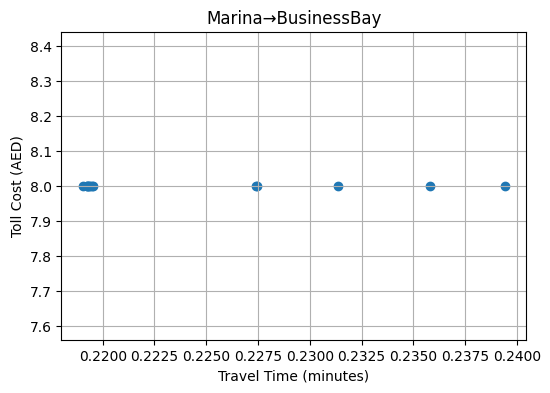

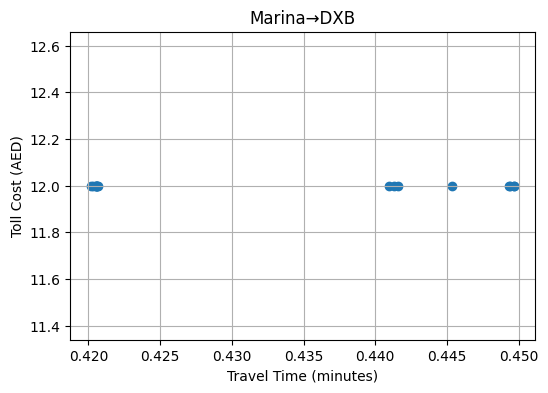

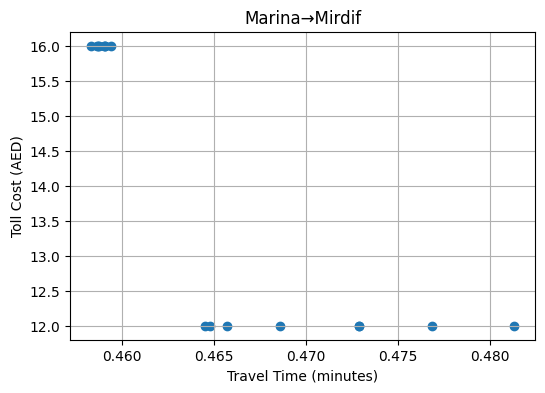

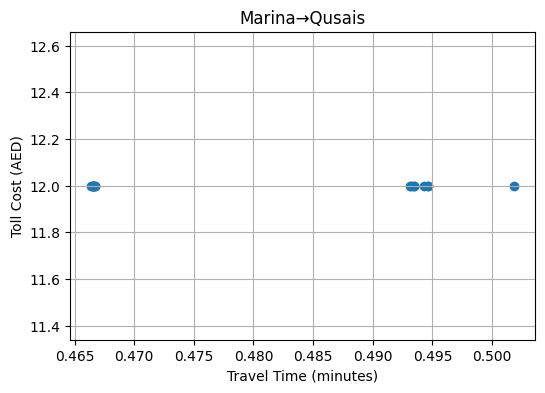

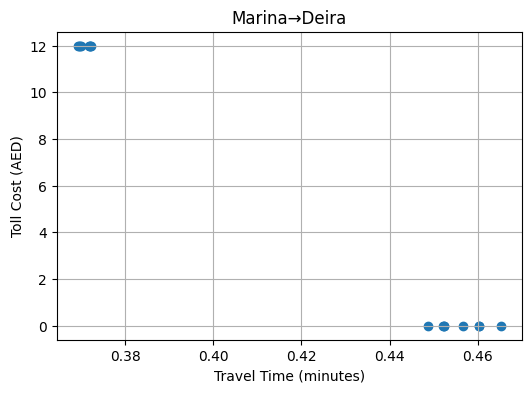

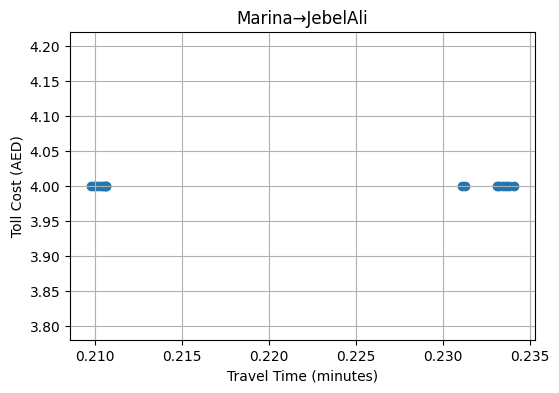

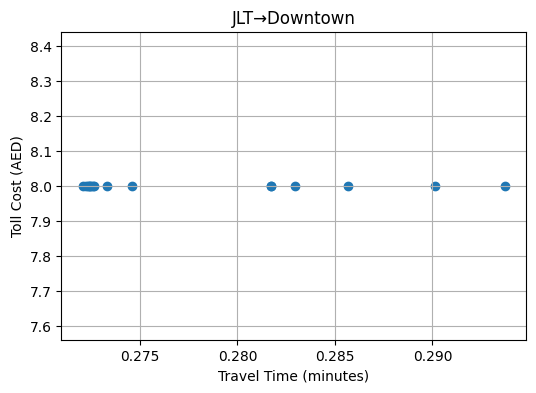

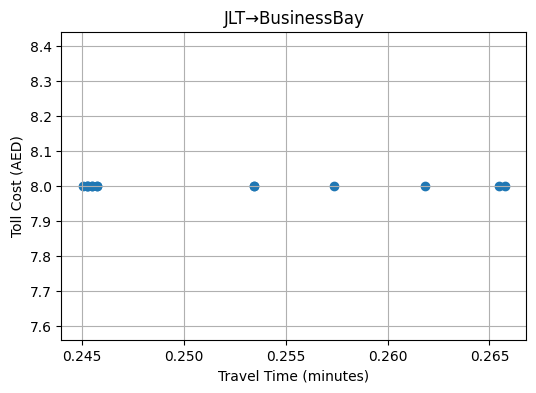

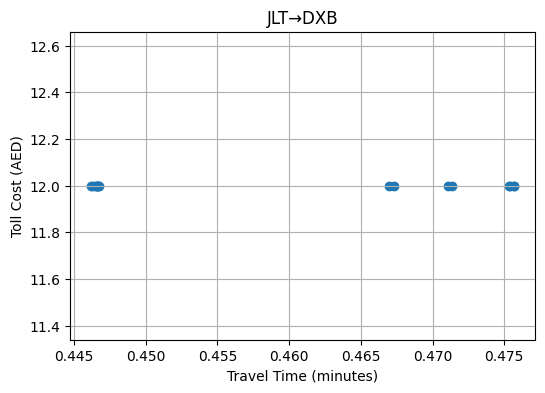

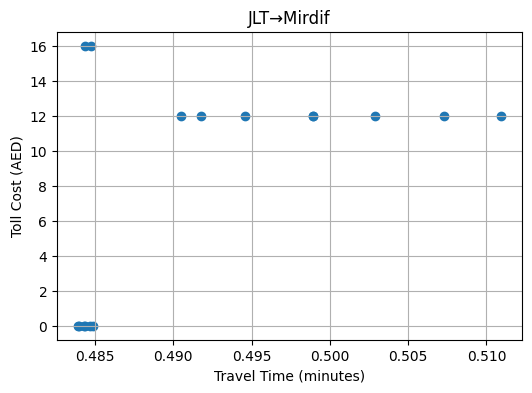

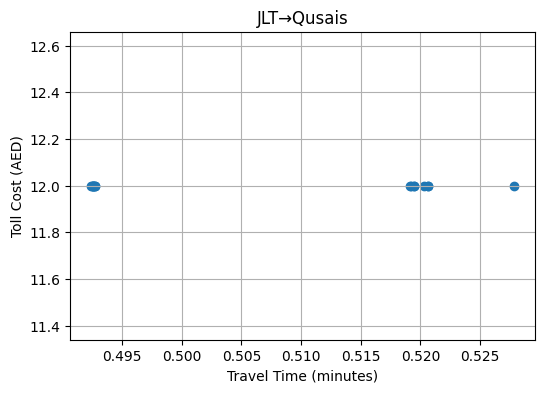

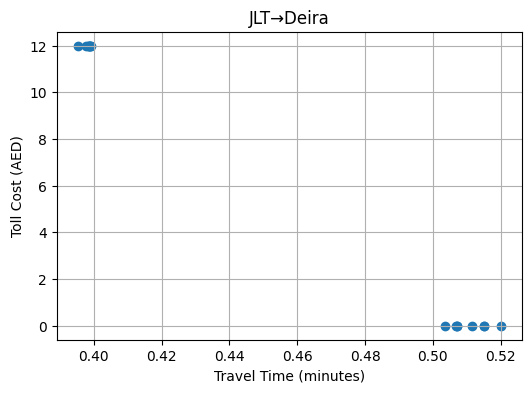

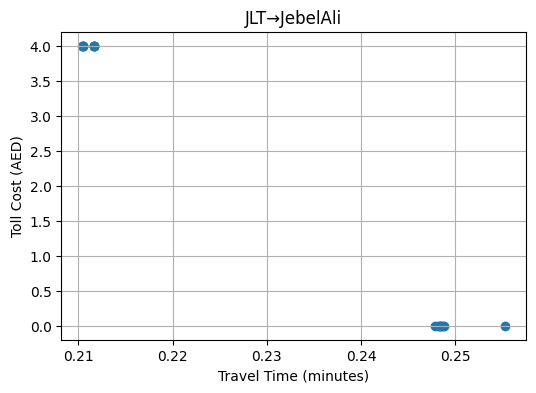

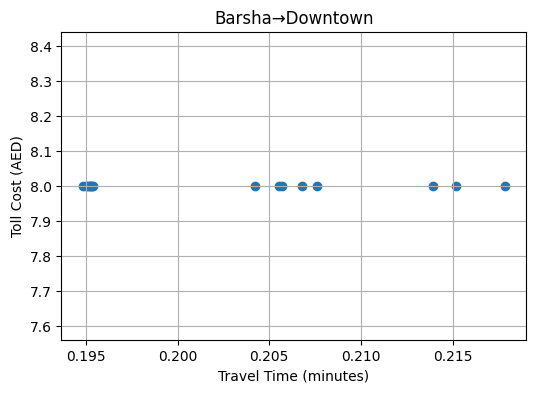

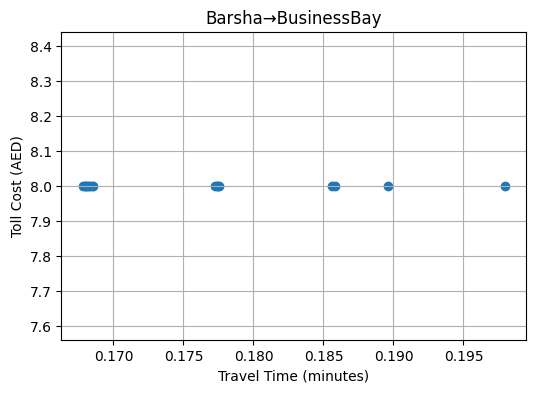

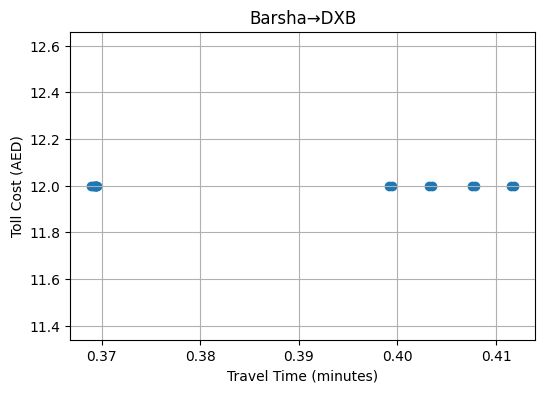

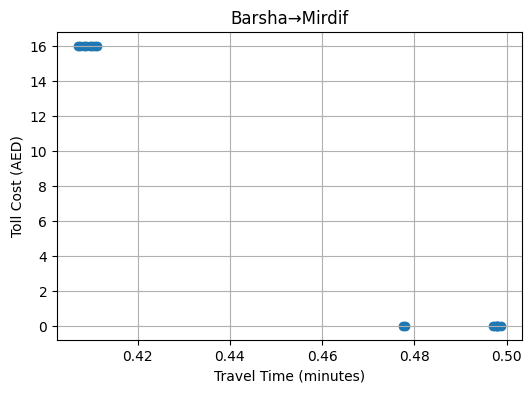

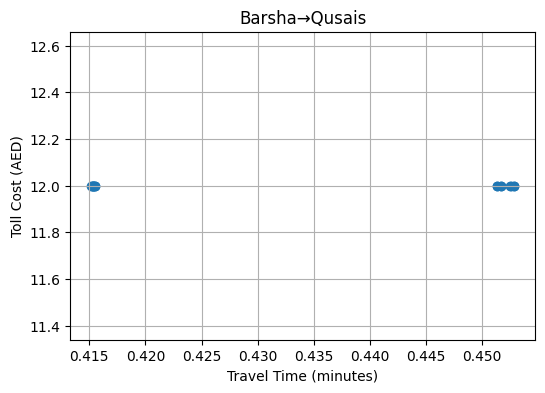

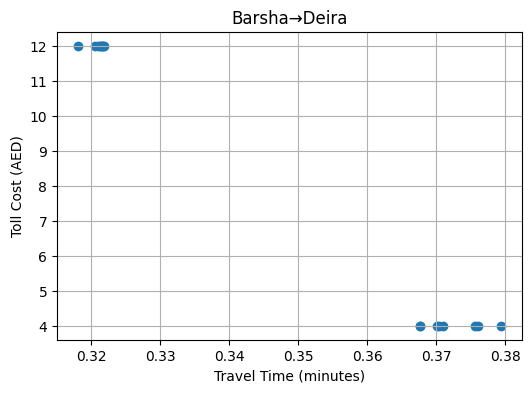

In [14]:
for res in results_all_pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(res["times"], res["tolls"])
    plt.xlabel("Travel Time (minutes)")
    plt.ylabel("Toll Cost (AED)")
    plt.title(res["name"])
    plt.grid(True)
    plt.show()

In [15]:
efficiency_rows = []

for res in results_all_pairs:
    times = res["times"]
    tolls = res["tolls"]

    zero_toll_times = [t for t, c in zip(times, tolls) if c == 0]

    # If no 0-toll option exists for this OD, skip efficiency for it
    if len(zero_toll_times) == 0:
        continue

    baseline_time = max(zero_toll_times)  # "avoid tolls" worst-case baseline

    for t, c in zip(times, tolls):
        if c > 0:
            minutes_saved = max(0, baseline_time - t)
            efficiency = minutes_saved / c
        else:
            efficiency = 0

        efficiency_rows.append([res["name"], t, c, efficiency])

eff_df = pd.DataFrame(
    efficiency_rows,
    columns=["Route", "Time", "Toll", "Minutes_per_AED"]
)

eff_df.head()

,Route,Time,Toll,Minutes_per_AED
0,Marina→Deira,0.369307,12.0,0.007993
1,Marina→Deira,0.369630,12.0,0.007966
2,Marina→Deira,0.369663,12.0,0.007963
3,Marina→Deira,0.369987,12.0,0.007936
4,Marina→Deira,0.371710,12.0,0.007792


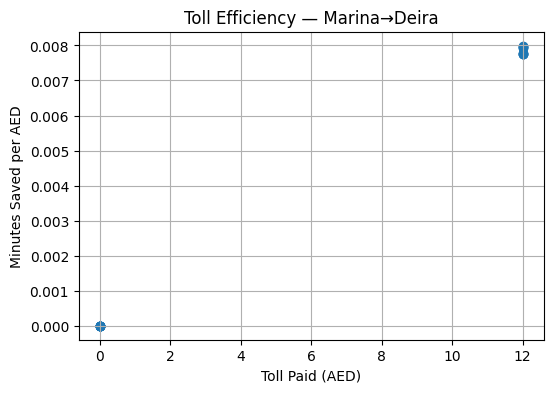

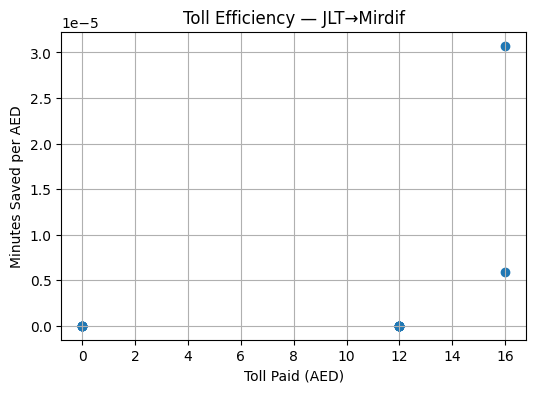

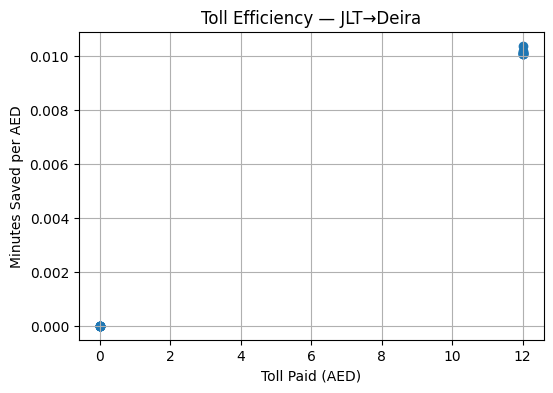

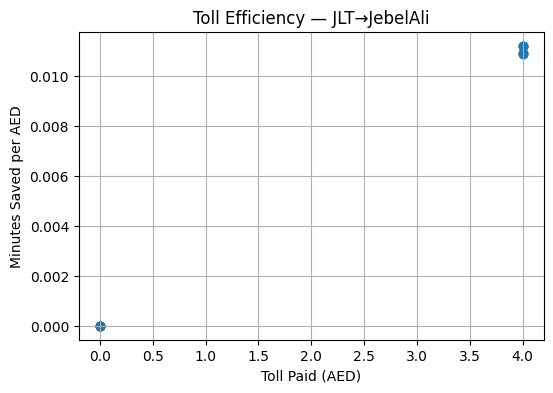

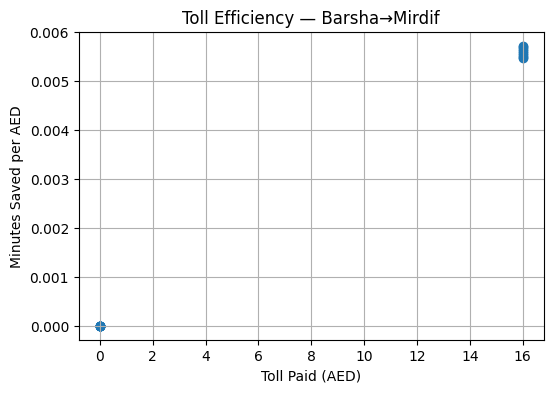

In [16]:
for route in eff_df["Route"].unique():
    sub = eff_df[eff_df["Route"] == route]

    plt.figure(figsize=(6, 4))
    plt.scatter(sub["Toll"], sub["Minutes_per_AED"])
    plt.xlabel("Toll Paid (AED)")
    plt.ylabel("Minutes Saved per AED")
    plt.title(f"Toll Efficiency — {route}")
    plt.grid(True)
    plt.show()